# Chapter 1 ASIC Baseline Evaluation Review

This notebook visualizes the saved ASIC Chapter 1 baseline evaluation package. It does **not** retrain models. All tables and figures below are read from saved artifacts under `artifacts/chapter1/evaluation/asic/baselines/primary_medians`.


## 1. Setup / Paths


In [1]:
from __future__ import annotations

import os
from pathlib import Path

import numpy as np
import pandas as pd

if "MPLCONFIGDIR" not in os.environ:
    mplconfigdir = Path("/tmp") / "chapter1_mortality_decomposition_matplotlib"
    mplconfigdir.mkdir(parents=True, exist_ok=True)
    os.environ["MPLCONFIGDIR"] = str(mplconfigdir)

try:
    from IPython import get_ipython
    ipython_shell = get_ipython()
    if ipython_shell is None:
        raise RuntimeError("Plain Python execution: use fallback display helpers.")
    from IPython.display import Markdown, display
except Exception:
    ipython_shell = None
    def Markdown(text: str) -> str:
        return text

    def display(obj: object) -> None:
        print(obj)

import matplotlib
if ipython_shell is None:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

def looks_like_repo_root(path: Path) -> bool:
    return (path / "pyproject.toml").exists() and (path / "src" / "chapter1_mortality_decomposition").exists()


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    search_roots = [start, *start.parents]
    for candidate in search_roots:
        if looks_like_repo_root(candidate):
            return candidate
    for anchor in search_roots:
        try:
            child_dirs = [child for child in anchor.iterdir() if child.is_dir()]
        except Exception:
            continue
        for child in child_dirs:
            if looks_like_repo_root(child):
                return child
    return start


WORKING_DIRECTORY = Path.cwd().resolve()
REPO_ROOT = find_repo_root(WORKING_DIRECTORY)
EVAL_ROOT = REPO_ROOT / "artifacts" / "chapter1" / "evaluation" / "asic" / "baselines" / "primary_medians"
MODELS = ["logistic_regression", "xgboost"]
HORIZONS = [8, 16, 24, 48, 72]
PRIMARY_HORIZON = 24

COMBINED_METRICS_PATH = EVAL_ROOT / "combined_metrics.csv"
REPORTING_SPLIT_SUMMARY_PATH = EVAL_ROOT / "reporting_split_summary.csv"
COMBINED_RISK_SUMMARY_PATH = EVAL_ROOT / "combined_risk_binned_summary.csv"
INTERPRETATION_NOTE_PATH = EVAL_ROOT / "interpretation_note.md"

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


def model_label(model_name: str) -> str:
    return {
        "logistic_regression": "Logistic Regression",
        "xgboost": "XGBoost",
    }.get(model_name, model_name.replace("_", " ").title())


def maybe_read_csv(path: Path) -> pd.DataFrame:
    return pd.read_csv(path) if path.exists() else pd.DataFrame()


def evaluation_image_path(model_name: str, relative_path: str) -> Path:
    return EVAL_ROOT / model_name / relative_path


def risk_summary_path(model_name: str, horizon_h: int) -> Path:
    return evaluation_image_path(model_name, f"horizon_{horizon_h}h/risk_binned_summary.csv")


def show_image_grid(paths: list[Path], titles: list[str], *, ncols: int = 3, figsize_scale: float = 4.5) -> None:
    if not paths:
        display(Markdown("_No figure paths provided._"))
        return
    nrows = int(np.ceil(len(paths) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_scale * ncols, figsize_scale * nrows))
    axes = np.atleast_1d(axes).reshape(-1)
    for ax, path, title in zip(axes, paths, titles):
        ax.set_title(title)
        if path.exists():
            ax.imshow(plt.imread(path))
            ax.axis("off")
        else:
            ax.axis("off")
            ax.text(0.5, 0.5, f"Missing figure\n{path.name}", ha="center", va="center")
    for ax in axes[len(paths):]:
        ax.axis("off")
    fig.tight_layout()
    plt.show()


display(Markdown(f"Working directory: `{WORKING_DIRECTORY}`"))
display(Markdown(f"Repository root: `{REPO_ROOT}`"))
display(Markdown(f"Evaluation root: `{EVAL_ROOT}`"))
display(Markdown(f"Artifacts available: `{EVAL_ROOT.exists()}`"))


Working directory: `/Users/joanameyer/repository/1-mortality-decomposition/notebooks`

Repository root: `/Users/joanameyer/repository/1-mortality-decomposition`

Evaluation root: `/Users/joanameyer/repository/1-mortality-decomposition/artifacts/chapter1/evaluation/asic/baselines/primary_medians`

Artifacts available: `True`

## 2. Load Prediction Outputs


In [2]:
combined_metrics = maybe_read_csv(COMBINED_METRICS_PATH)
reporting_split_summary = maybe_read_csv(REPORTING_SPLIT_SUMMARY_PATH)
combined_risk_summary = maybe_read_csv(COMBINED_RISK_SUMMARY_PATH)
interpretation_note = INTERPRETATION_NOTE_PATH.read_text() if INTERPRETATION_NOTE_PATH.exists() else "_Missing interpretation note._"

if not combined_metrics.empty and not reporting_split_summary.empty:
    reporting_metrics = combined_metrics.merge(
        reporting_split_summary[["model_name", "horizon_h", "selected_split", "selection_reason", "selected_split_evaluable"]],
        left_on=["model_name", "horizon_h", "split"],
        right_on=["model_name", "horizon_h", "selected_split"],
        how="inner",
    )
else:
    reporting_metrics = pd.DataFrame()

display(Markdown("### Reporting Split Selection"))
display(reporting_split_summary)

display(Markdown("### Combined Metric Rows"))
display(combined_metrics.head(12))


### Reporting Split Selection

,model_name,horizon_h,selected_split,selected_split_evaluable,selection_reason,sample_count,event_count,non_event_count
0,logistic_regression,8,validation,True,first_binary_evaluable_split_in_priority_order,244,2,242
1,logistic_regression,16,validation,True,first_binary_evaluable_split_in_priority_order,243,4,239
2,logistic_regression,24,validation,True,first_binary_evaluable_split_in_priority_order,242,6,236
3,logistic_regression,48,validation,True,first_binary_evaluable_split_in_priority_order,239,12,227
4,logistic_regression,72,validation,True,first_binary_evaluable_split_in_priority_order,236,18,218
5,xgboost,8,validation,True,first_binary_evaluable_split_in_priority_order,244,2,242
6,xgboost,16,validation,True,first_binary_evaluable_split_in_priority_order,243,4,239
7,xgboost,24,validation,True,first_binary_evaluable_split_in_priority_order,242,6,236
8,xgboost,48,validation,True,first_binary_evaluable_split_in_priority_order,239,12,227
9,xgboost,72,validation,True,first_binary_evaluable_split_in_priority_order,236,18,218


### Combined Metric Rows

,model_name,horizon_h,split,sample_count,event_count,non_event_count,event_rate,auroc,auprc,calibration_intercept,calibration_slope,metric_notes,brier_score,binary_metrics_evaluable,finite_prediction_count
0,logistic_regression,8,test,235,0,235,0.000000,NaN,NaN,NaN,NaN,auroc_unavailable_single_class; auprc_unavaila...,0.000970,False,235
1,logistic_regression,8,train,777,8,769,0.010296,0.877438,0.448315,0.998228,1.307092,NaN,0.008154,True,777
2,logistic_regression,8,validation,244,2,242,0.008197,0.419421,0.011898,-5.880084,-0.170403,NaN,0.011678,True,244
3,logistic_regression,16,test,231,0,231,0.000000,NaN,NaN,NaN,NaN,auroc_unavailable_single_class; auprc_unavaila...,0.000906,False,231
4,logistic_regression,16,train,770,16,754,0.020779,0.828001,0.277959,0.303407,1.102086,NaN,0.017810,True,770
5,logistic_regression,16,validation,243,4,239,0.016461,0.654812,0.058796,-2.392905,0.387449,NaN,0.017934,True,243
6,logistic_regression,24,test,227,0,227,0.000000,NaN,NaN,NaN,NaN,auroc_unavailable_single_class; auprc_unavaila...,0.002229,False,227
7,logistic_regression,24,train,763,24,739,0.031455,0.740528,0.311894,0.169108,1.059443,NaN,0.026668,True,763
8,logistic_regression,24,validation,242,6,236,0.024793,0.740819,0.115801,-1.476574,0.630244,NaN,0.025735,True,242
9,logistic_regression,48,test,215,0,215,0.000000,NaN,NaN,NaN,NaN,auroc_unavailable_single_class; auprc_unavaila...,0.007373,False,215


## 3. Discrimination Metrics Summary


,model_name,horizon_h,selected_split,sample_count,event_count,auroc,auprc,metric_notes
0,logistic_regression,8,validation,244,2,0.419421,0.011898,NaN
1,logistic_regression,16,validation,243,4,0.654812,0.058796,NaN
2,logistic_regression,24,validation,242,6,0.740819,0.115801,NaN
3,logistic_regression,48,validation,239,12,0.569750,0.085797,NaN
4,logistic_regression,72,validation,236,18,0.654434,0.142132,NaN
5,xgboost,8,validation,244,2,0.551653,0.022477,NaN
6,xgboost,16,validation,243,4,0.573222,0.023582,NaN
7,xgboost,24,validation,242,6,0.514124,0.032334,NaN
8,xgboost,48,validation,239,12,0.573421,0.062842,NaN
9,xgboost,72,validation,236,18,0.723751,0.165580,NaN


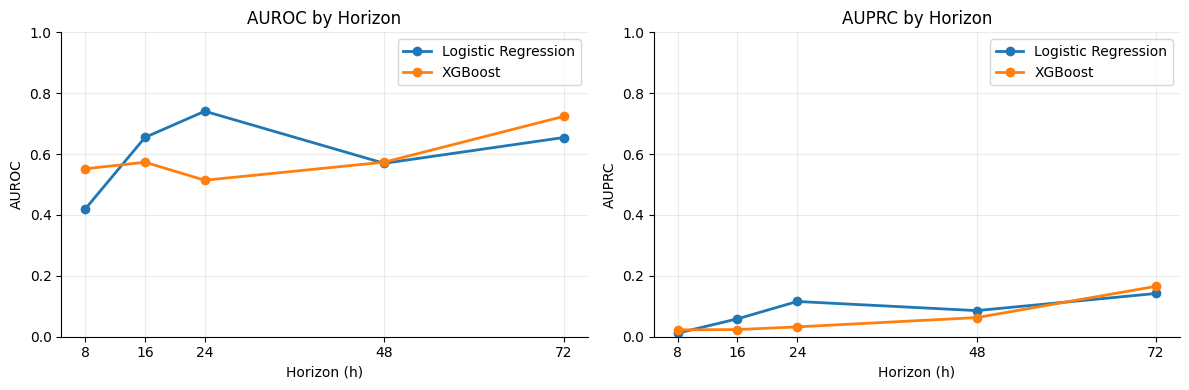

In [3]:
if reporting_metrics.empty:
    display(Markdown("_Reporting metrics are missing._"))
else:
    discrimination_table = reporting_metrics[
        ["model_name", "horizon_h", "selected_split", "sample_count", "event_count", "auroc", "auprc", "metric_notes"]
    ].sort_values(["model_name", "horizon_h"])
    display(discrimination_table)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
    for model_name in MODELS:
        subset = reporting_metrics[reporting_metrics["model_name"].eq(model_name)].sort_values("horizon_h")
        axes[0].plot(subset["horizon_h"], subset["auroc"], marker="o", linewidth=2, label=model_label(model_name))
        axes[1].plot(subset["horizon_h"], subset["auprc"], marker="o", linewidth=2, label=model_label(model_name))
    axes[0].set_title("AUROC by Horizon")
    axes[1].set_title("AUPRC by Horizon")
    for ax in axes:
        ax.set_xlabel("Horizon (h)")
        ax.set_xticks(HORIZONS)
        ax.set_ylim(0.0, 1.0)
        ax.grid(alpha=0.25)
        ax.legend()
    axes[0].set_ylabel("AUROC")
    axes[1].set_ylabel("AUPRC")
    plt.tight_layout()
    plt.show()


## 4. Calibration Summary


,model_name,horizon_h,selected_split,calibration_intercept,calibration_slope,brier_score,metric_notes
0,logistic_regression,8,validation,-5.880084,-0.170403,0.011678,NaN
1,logistic_regression,16,validation,-2.392905,0.387449,0.017934,NaN
2,logistic_regression,24,validation,-1.476574,0.630244,0.025735,NaN
3,logistic_regression,48,validation,-2.227094,0.235836,0.056070,NaN
4,logistic_regression,72,validation,-1.597962,0.340322,0.082065,NaN
5,xgboost,8,validation,-4.054148,0.137427,0.010305,NaN
6,xgboost,16,validation,-3.798413,0.060936,0.021675,NaN
7,xgboost,24,validation,-3.605067,0.016001,0.035780,NaN
8,xgboost,48,validation,-2.574175,0.136931,0.074249,NaN
9,xgboost,72,validation,-1.596063,0.422744,0.091556,NaN


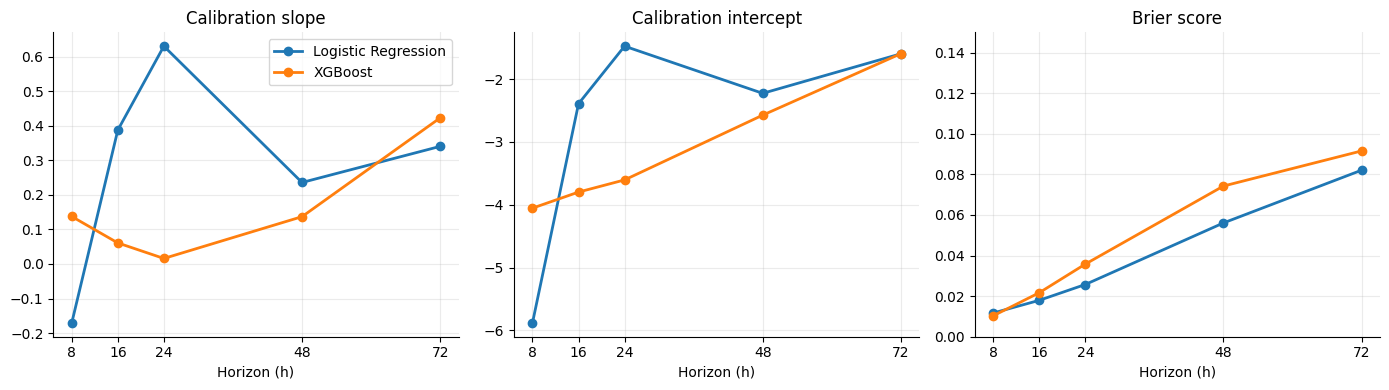

In [4]:
if reporting_metrics.empty:
    display(Markdown("_Reporting metrics are missing._"))
else:
    calibration_table = reporting_metrics[
        [
            "model_name",
            "horizon_h",
            "selected_split",
            "calibration_intercept",
            "calibration_slope",
            "brier_score",
            "metric_notes",
        ]
    ].sort_values(["model_name", "horizon_h"])
    display(calibration_table)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True)
    metric_specs = [
        ("calibration_slope", "Calibration slope", None),
        ("calibration_intercept", "Calibration intercept", None),
        ("brier_score", "Brier score", (0.0, 0.15)),
    ]
    for axis, (column, label, ylim) in zip(axes, metric_specs):
        for model_name in MODELS:
            subset = reporting_metrics[reporting_metrics["model_name"].eq(model_name)].sort_values("horizon_h")
            axis.plot(subset["horizon_h"], subset[column], marker="o", linewidth=2, label=model_label(model_name))
        axis.set_title(label)
        axis.set_xlabel("Horizon (h)")
        axis.set_xticks(HORIZONS)
        axis.grid(alpha=0.25)
        if ylim is not None:
            axis.set_ylim(*ylim)
    axes[0].legend()
    plt.tight_layout()
    plt.show()


## 5. Reliability Plots


### Logistic Regression

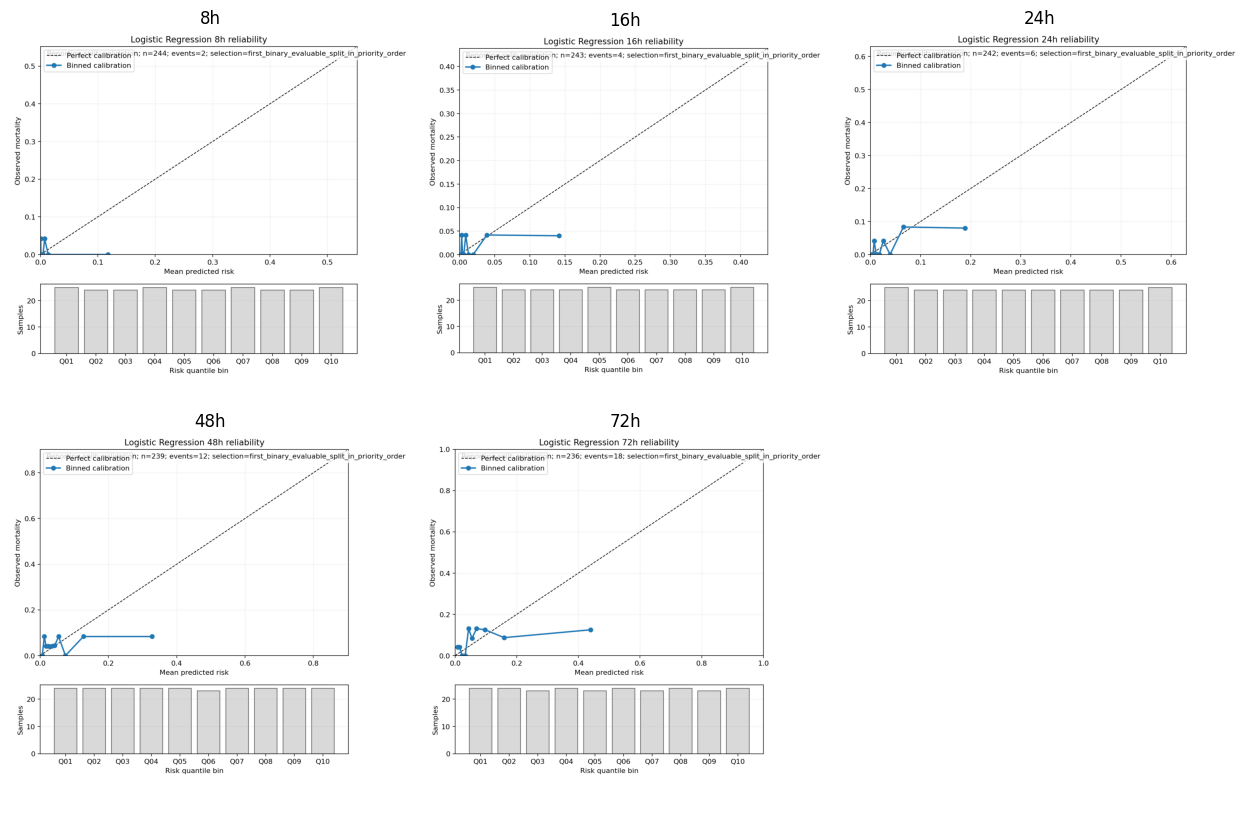

### XGBoost

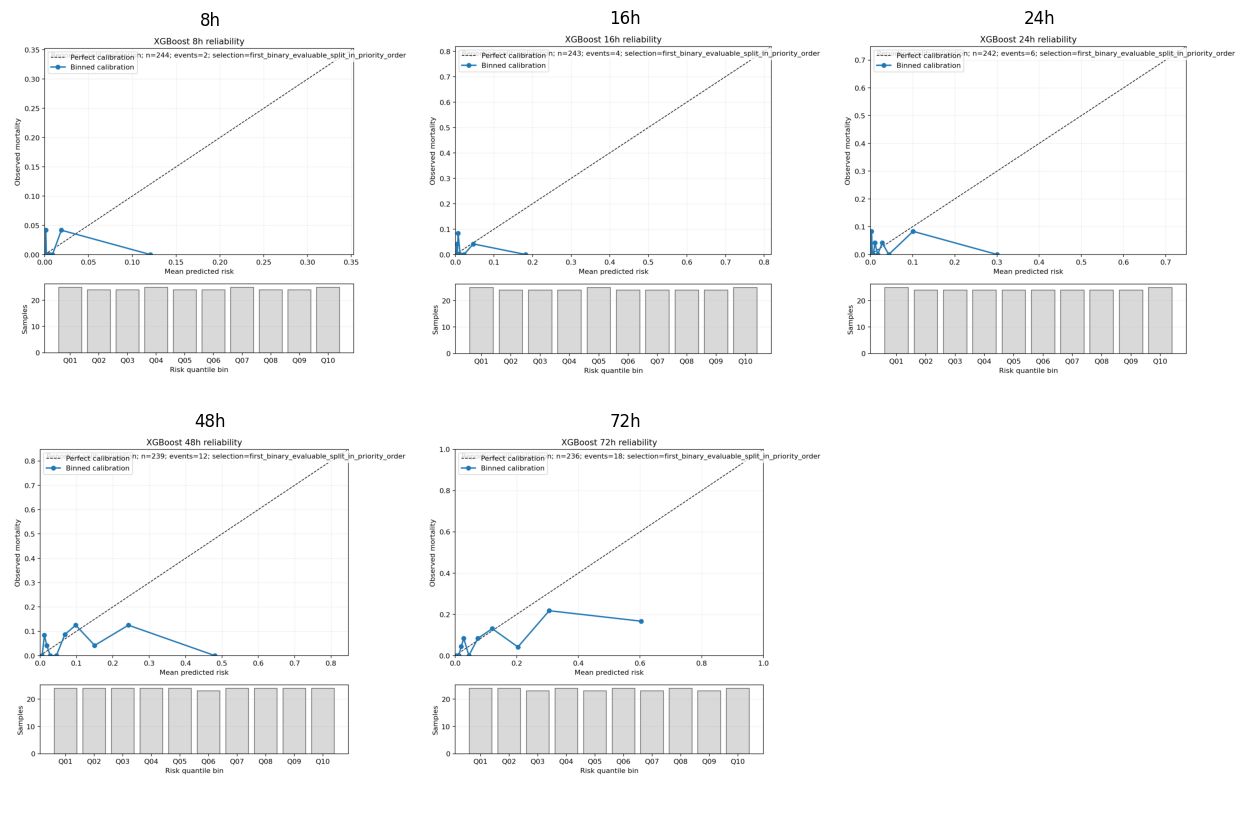

In [5]:
for model_name in MODELS:
    display(Markdown(f"### {model_label(model_name)}"))
    image_paths = [
        evaluation_image_path(model_name, f"horizon_{horizon_h}h/reliability_plot.png")
        for horizon_h in HORIZONS
    ]
    titles = [f"{horizon_h}h" for horizon_h in HORIZONS]
    show_image_grid(image_paths, titles, ncols=3, figsize_scale=4.2)


## 6. Mortality-vs-Risk Plots


### Logistic Regression

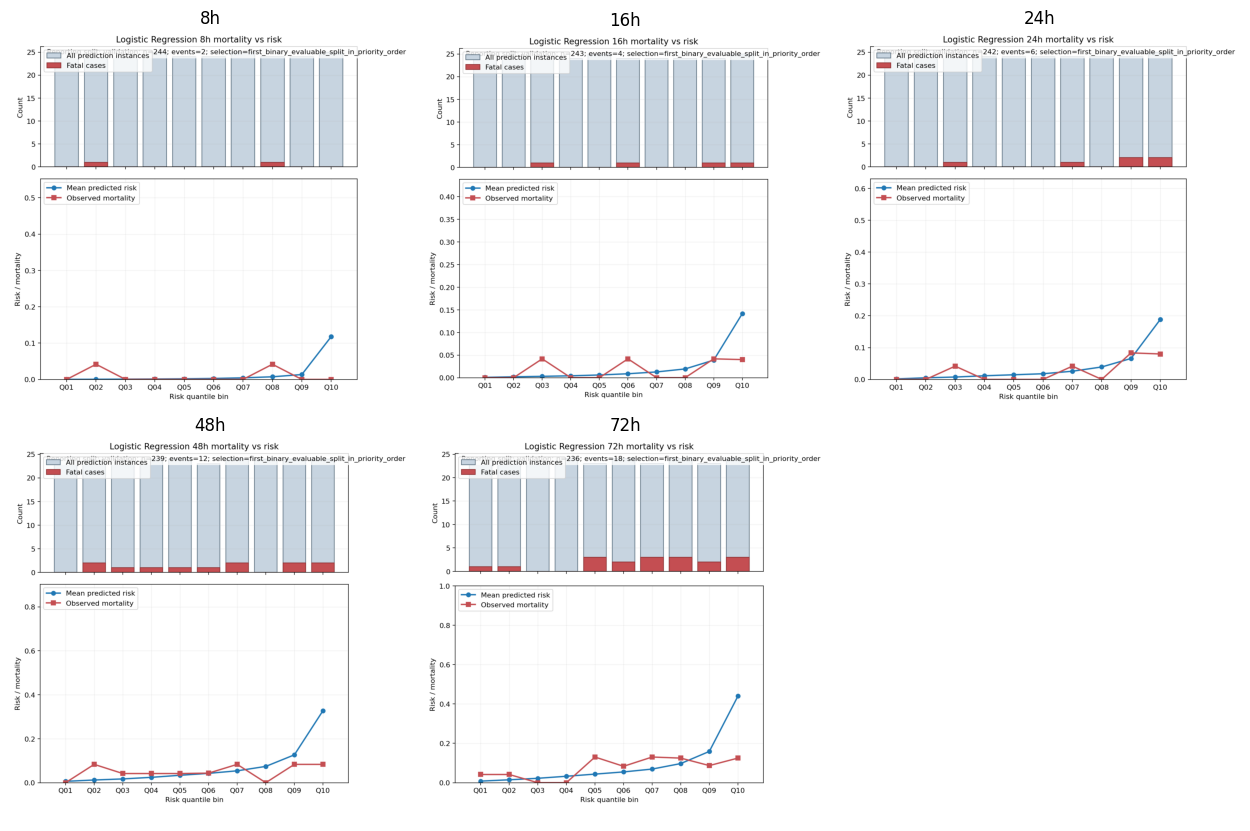

### XGBoost

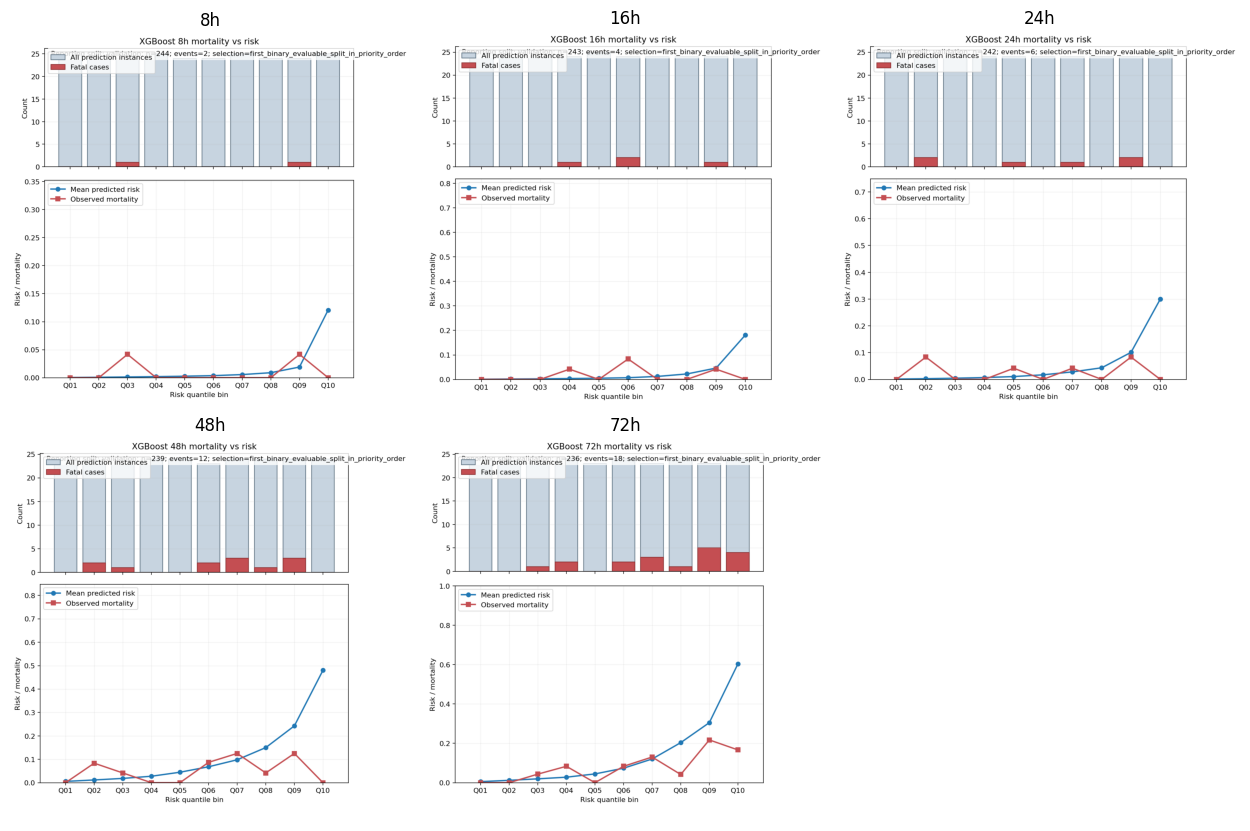

### Saved Reporting-Split Risk-Binned Summary

,model_name,horizon_h,split,sample_scope,group_id,bin_index,bin_label,sample_count,event_count,non_event_count,sample_fraction,event_fraction_of_events,predicted_probability_mean,predicted_probability_min,predicted_probability_max,observed_mortality
0,logistic_regression,8,validation,overall,overall,1,Q01,25,0,25,0.102459,0.00,0.000130,0.000012,0.000223,0.000000
1,logistic_regression,8,validation,overall,overall,2,Q02,24,1,23,0.098361,0.50,0.000372,0.000269,0.000506,0.041667
2,logistic_regression,8,validation,overall,overall,3,Q03,24,0,24,0.098361,0.00,0.000685,0.000531,0.000873,0.000000
3,logistic_regression,8,validation,overall,overall,4,Q04,25,0,25,0.102459,0.00,0.001077,0.000876,0.001362,0.000000
4,logistic_regression,8,validation,overall,overall,5,Q05,24,0,24,0.098361,0.00,0.001686,0.001364,0.002082,0.000000
5,logistic_regression,8,validation,overall,overall,6,Q06,24,0,24,0.098361,0.00,0.002631,0.002125,0.003421,0.000000
6,logistic_regression,8,validation,overall,overall,7,Q07,25,0,25,0.102459,0.00,0.004311,0.003519,0.005431,0.000000
7,logistic_regression,8,validation,overall,overall,8,Q08,24,1,23,0.098361,0.50,0.007205,0.005695,0.009573,0.041667
8,logistic_regression,8,validation,overall,overall,9,Q09,24,0,24,0.098361,0.00,0.013355,0.009615,0.018153,0.000000
9,logistic_regression,8,validation,overall,overall,10,Q10,25,0,25,0.102459,0.00,0.117722,0.018586,0.502028,0.000000


In [6]:
for model_name in MODELS:
    display(Markdown(f"### {model_label(model_name)}"))
    image_paths = [
        evaluation_image_path(model_name, f"horizon_{horizon_h}h/mortality_vs_risk_plot.png")
        for horizon_h in HORIZONS
    ]
    titles = [f"{horizon_h}h" for horizon_h in HORIZONS]
    show_image_grid(image_paths, titles, ncols=3, figsize_scale=4.2)

display(Markdown("### Saved Reporting-Split Risk-Binned Summary"))
display(combined_risk_summary.head(20))


## 7. Horizon Comparison


### Logistic Regression

,model_name,horizon_h,split,sample_count,event_count,non_event_count,event_rate,auroc,auprc,calibration_intercept,calibration_slope,metric_notes,brier_score,binary_metrics_evaluable,finite_prediction_count,selected_split,selected_split_evaluable,selection_reason,evaluation_metadata_path
0,logistic_regression,8,validation,244,2,242,0.008197,0.419421,0.011898,-5.880084,-0.170403,NaN,0.011678,True,244,validation,True,first_binary_evaluable_split_in_priority_order,/Users/joanameyer/repository/1-mortality-decom...
1,logistic_regression,16,validation,243,4,239,0.016461,0.654812,0.058796,-2.392905,0.387449,NaN,0.017934,True,243,validation,True,first_binary_evaluable_split_in_priority_order,/Users/joanameyer/repository/1-mortality-decom...
2,logistic_regression,24,validation,242,6,236,0.024793,0.740819,0.115801,-1.476574,0.630244,NaN,0.025735,True,242,validation,True,first_binary_evaluable_split_in_priority_order,/Users/joanameyer/repository/1-mortality-decom...
3,logistic_regression,48,validation,239,12,227,0.050209,0.569750,0.085797,-2.227094,0.235836,NaN,0.056070,True,239,validation,True,first_binary_evaluable_split_in_priority_order,/Users/joanameyer/repository/1-mortality-decom...
4,logistic_regression,72,validation,236,18,218,0.076271,0.654434,0.142132,-1.597962,0.340322,NaN,0.082065,True,236,validation,True,first_binary_evaluable_split_in_priority_order,/Users/joanameyer/repository/1-mortality-decom...


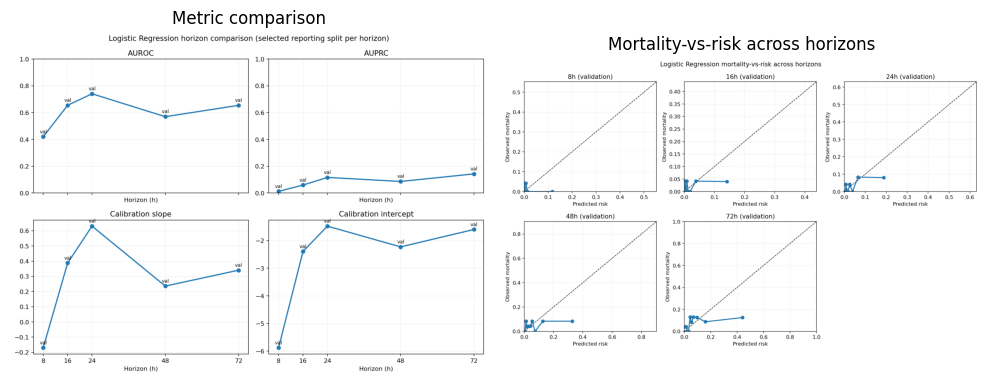

### XGBoost

,model_name,horizon_h,split,sample_count,event_count,non_event_count,event_rate,auroc,auprc,calibration_intercept,calibration_slope,metric_notes,brier_score,binary_metrics_evaluable,finite_prediction_count,selected_split,selected_split_evaluable,selection_reason,evaluation_metadata_path
0,xgboost,8,validation,244,2,242,0.008197,0.551653,0.022477,-4.054148,0.137427,NaN,0.010305,True,244,validation,True,first_binary_evaluable_split_in_priority_order,/Users/joanameyer/repository/1-mortality-decom...
1,xgboost,16,validation,243,4,239,0.016461,0.573222,0.023582,-3.798413,0.060936,NaN,0.021675,True,243,validation,True,first_binary_evaluable_split_in_priority_order,/Users/joanameyer/repository/1-mortality-decom...
2,xgboost,24,validation,242,6,236,0.024793,0.514124,0.032334,-3.605067,0.016001,NaN,0.035780,True,242,validation,True,first_binary_evaluable_split_in_priority_order,/Users/joanameyer/repository/1-mortality-decom...
3,xgboost,48,validation,239,12,227,0.050209,0.573421,0.062842,-2.574175,0.136931,NaN,0.074249,True,239,validation,True,first_binary_evaluable_split_in_priority_order,/Users/joanameyer/repository/1-mortality-decom...
4,xgboost,72,validation,236,18,218,0.076271,0.723751,0.165580,-1.596063,0.422744,NaN,0.091556,True,236,validation,True,first_binary_evaluable_split_in_priority_order,/Users/joanameyer/repository/1-mortality-decom...


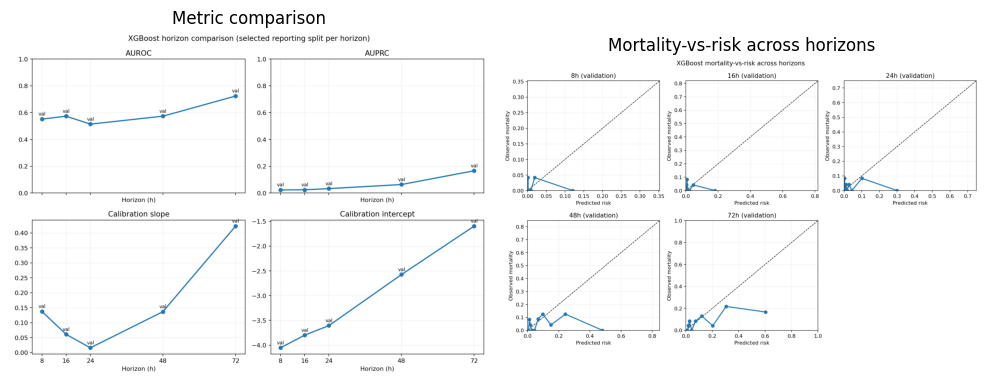

In [7]:
for model_name in MODELS:
    display(Markdown(f"### {model_label(model_name)}"))
    horizon_metrics_path = evaluation_image_path(model_name, "horizon_comparison_metrics.csv")
    horizon_metrics = maybe_read_csv(horizon_metrics_path)
    display(horizon_metrics)
    show_image_grid(
        [
            evaluation_image_path(model_name, "horizon_comparison_plot.png"),
            evaluation_image_path(model_name, "horizon_risk_structure_grid.png"),
        ],
        ["Metric comparison", "Mortality-vs-risk across horizons"],
        ncols=2,
        figsize_scale=5.0,
    )


## 8. Site-Stratified Sanity Check


### Logistic Regression primary 24h site summary

,model_name,horizon_h,split,hospital_id,sample_count,event_count,non_event_count,event_rate,auroc,auprc,calibration_intercept,calibration_slope,metric_notes,brier_score,binary_metrics_evaluable,finite_prediction_count
0,logistic_regression,24,validation,asic_UK02,49,3,46,0.061224,0.789855,0.215025,-0.861913,0.727624,NaN,0.059479,True,49
1,logistic_regression,24,validation,asic_UK04,25,0,25,0.000000,NaN,NaN,NaN,NaN,auroc_unavailable_single_class; auprc_unavaila...,0.012965,False,25
2,logistic_regression,24,validation,asic_UK07,13,3,10,0.230769,0.533333,0.361111,-0.818577,0.098790,NaN,0.218714,True,13
3,logistic_regression,24,validation,asic_UK08,155,0,155,0.000000,NaN,NaN,NaN,NaN,auroc_unavailable_single_class; auprc_unavaila...,0.000941,False,155


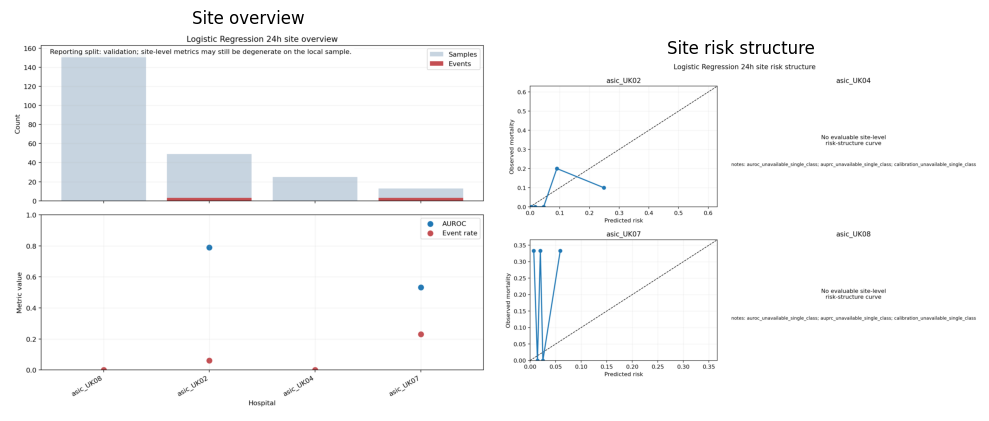

### XGBoost primary 24h site summary

,model_name,horizon_h,split,hospital_id,sample_count,event_count,non_event_count,event_rate,auroc,auprc,calibration_intercept,calibration_slope,metric_notes,brier_score,binary_metrics_evaluable,finite_prediction_count
0,xgboost,24,validation,asic_UK02,49,3,46,0.061224,0.456522,0.071096,-2.804589,-0.028281,NaN,0.095062,True,49
1,xgboost,24,validation,asic_UK04,25,0,25,0.000000,NaN,NaN,NaN,NaN,auroc_unavailable_single_class; auprc_unavaila...,0.012925,False,25
2,xgboost,24,validation,asic_UK07,13,3,10,0.230769,0.033333,0.165812,-16.149468,-3.325597,NaN,0.237792,True,13
3,xgboost,24,validation,asic_UK08,155,0,155,0.000000,NaN,NaN,NaN,NaN,auroc_unavailable_single_class; auprc_unavaila...,0.003783,False,155


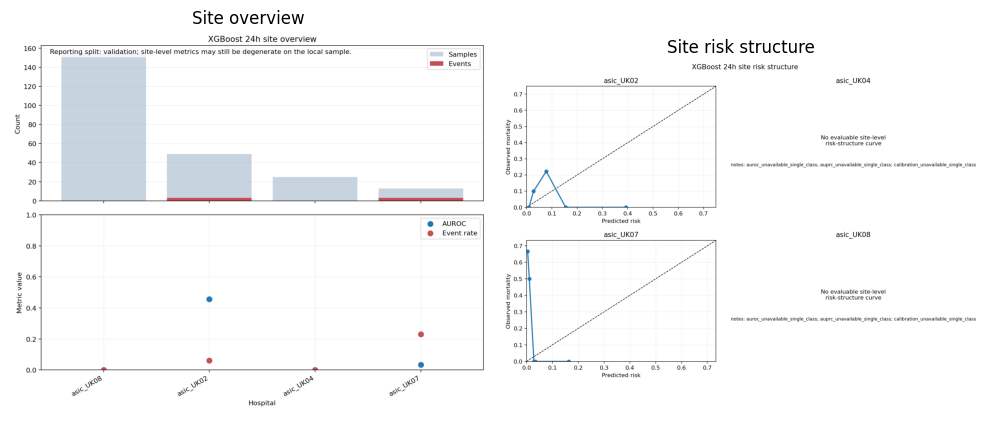

In [8]:
for model_name in MODELS:
    display(Markdown(f"### {model_label(model_name)} primary {PRIMARY_HORIZON}h site summary"))
    site_summary = maybe_read_csv(evaluation_image_path(model_name, f"primary_{PRIMARY_HORIZON}h_site_summary.csv"))
    display(site_summary)
    show_image_grid(
        [
            evaluation_image_path(model_name, f"primary_{PRIMARY_HORIZON}h_site_overview.png"),
            evaluation_image_path(model_name, f"primary_{PRIMARY_HORIZON}h_site_risk_structure.png"),
        ],
        ["Site overview", "Site risk structure"],
        ncols=2,
        figsize_scale=5.0,
    )


## 9. Short Interpretation Note / Markdown Summary


In [9]:
display(Markdown(interpretation_note))


# Chapter 1 ASIC Baseline Evaluation: First-Pass Interpretation

Models evaluated: Logistic Regression, XGBoost.
Horizons evaluated: 8h, 16h, 24h, 48h, 72h.
Reporting split usage across model-horizon pairs: validation=10.

At least one horizon had to fall back from the frozen test split to another existing split because the local sample test partition was not binary-evaluable.
Calibration curves are descriptive enough to inspect risk ordering on the currently selected holdout split, but they should still be treated as preliminary until the full ASIC test set is run.
No single hospital obviously dominates the primary-horizon evaluation rows in the current sample, although several site-level metrics remain sparse.

Primary 24h summary:
- Logistic Regression 24h used the `validation` split (AUROC 0.741, AUPRC 0.116, calibration slope 0.630).
- XGBoost 24h used the `validation` split (AUROC 0.514, AUPRC 0.032, calibration slope 0.016).

Caveats:
- This run is still sample-limited, especially on the frozen test split where local smoke-test artifacts can contain no events.
- Discrimination, calibration, and site-level plots should therefore be interpreted as pipeline-validation outputs first, and scientific evidence second.
- Later hard-case analysis should wait for the full ASIC evaluation run on a binary-evaluable holdout split.